![Differential privacy](assets/headers/differential-privacy.jpg)

# 03. Differential privacy

A hospital statistics service answers counts and never releases a patient record. We show that
enough counts still let an attacker rebuild every diagnosis, then see how Laplace noise and a
privacy budget limit what the attacker learns.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer

## Setup

Tested with Python 3.11. The next cell installs the package versions used in this notebook.

In [1]:
%pip install --quiet numpy==1.26.4 pandas==2.2.3 scipy==1.13.1 scikit-learn==1.5.0 \
    matplotlib==3.9.4 diffprivlib==0.6.5

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from diffprivlib import BudgetAccountant
from diffprivlib.mechanisms import Laplace
from diffprivlib.utils import BudgetError
from scipy.linalg import pinv
from sklearn.datasets import load_breast_cancer

# Colours used in the figures
NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. The data and the count query

We use the Wisconsin breast-cancer dataset from scikit-learn: 569 patients, each with a benign or
malignant diagnosis. In our story the patient IDs are public and the diagnoses are private. The
hospital answers one kind of question: *how many of these patients have a malignant tumour?*

In [3]:
data = load_breast_cancer()
diagnosis = (data.target == 0).astype(int)  # 1 = malignant, 0 = benign
n_patients = len(diagnosis)
print(f"{n_patients} patients, {diagnosis.sum()} malignant")

569 patients, 212 malignant


The privacy unit is one patient's diagnosis: two neighbouring datasets differ in the diagnosis of
one patient. Changing one diagnosis moves any count by at most 1, so a count has sensitivity 1.
That holds only if each patient is counted once.

In [4]:
def count_malignant(patient_ids):
    """Number of malignant diagnoses among the given patients."""
    # A patient listed twice would count twice, so drop duplicate IDs (sensitivity stays 1)
    return diagnosis[np.unique(patient_ids)].sum()


cohort = np.arange(15, 25)
print("Malignant among patients 15-24:", count_malignant(cohort))
print("Same, with patient 15 listed three more times:", count_malignant([15, 15, 15, *cohort]))
print("Without dropping duplicates it would be:", diagnosis[[15, 15, 15, *cohort]].sum())

Malignant among patients 15-24: 7
Same, with patient 15 listed three more times: 7
Without dropping duplicates it would be: 10


## 2. Reconstruction attack on exact counts

No answer names a patient, but every answer is an equation. If a cohort holds patients 3, 8 and 9
and its answer is $a$, then $d_3 + d_8 + d_9 = a$, where $d_i$ is patient $i$'s diagnosis.

The attacker picks 1,138 random cohorts (twice the number of patients), each containing about half
of the patients, and asks for the count of each one. That gives 1,138 equations for 569 unknowns.

In [5]:
n_queries = 2 * n_patients
rng = np.random.default_rng(0)
query_matrix = rng.integers(0, 2, size=(n_queries, n_patients))  # row i: 1 = patient is in cohort i

exact_answers = np.array([count_malignant(np.flatnonzero(row)) for row in query_matrix])
print(f"{n_queries} queries. First five answers: {exact_answers[:5]}")

1138 queries. First five answers: [122 111 102 118 110]


The attacker knows the cohorts (`query_matrix`) and the answers. Least squares finds the diagnoses
$d$ that best fit `query_matrix @ d = answers`. The estimates are real numbers, so the attacker
rounds each one at 0.5.

In [6]:
solver = pinv(query_matrix)  # least-squares solution: d = solver @ answers


def reconstruction_rate(answers):
    """Share of diagnoses the attacker gets right."""
    guess = (solver @ answers >= 0.5).astype(int)
    return (guess == diagnosis).mean()


majority = 1 - diagnosis.mean()  # share of benign patients, the most common diagnosis
print(f"Exact counts: {reconstruction_rate(exact_answers):.1%} of diagnoses reconstructed")
print(f"Guessing 'benign' for everyone: {majority:.1%} correct")

Exact counts: 100.0% of diagnoses reconstructed
Guessing 'benign' for everyone: 62.7% correct


Every diagnosis comes back, although the service never released a record. Guessing the most common
diagnosis for everyone scores 62.7% without asking anything, so any result above that is
information leaked by the counts.

## 3. Laplace noise

Differential privacy limits how much one person can change what is released: whether a given
patient's diagnosis is benign or malignant, the answers should look almost the same. For a count,
it does this by adding random noise. The Laplace mechanism draws the noise with scale
sensitivity / ε, which for a count is 1/ε. Smaller ε means wider noise and stronger protection.
Larger ε means more precise answers and more privacy loss.

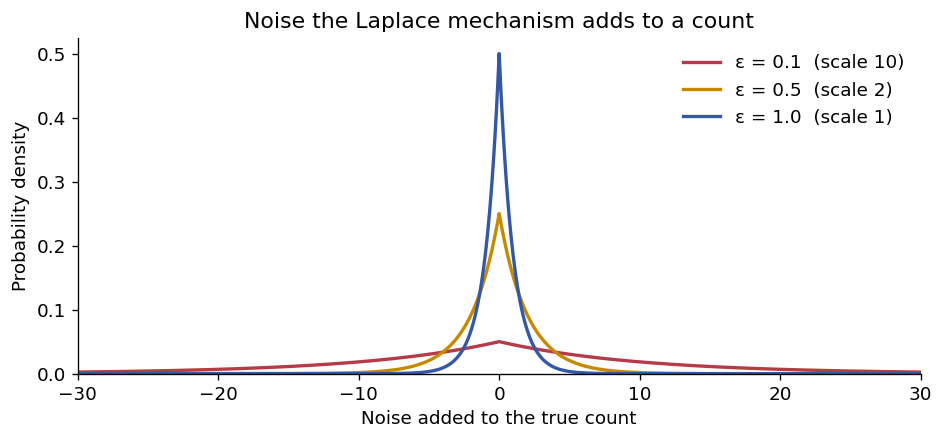

In [7]:
noise = np.linspace(-30, 30, 601)
fig, ax = plt.subplots(figsize=(8, 3.8))
for epsilon, colour in [(0.1, RED), (0.5, GOLD), (1.0, BLUE)]:
    density = epsilon / 2 * np.exp(-epsilon * np.abs(noise))  # Laplace density with scale 1/ε
    ax.plot(noise, density, color=colour, lw=2, label=f"ε = {epsilon}  (scale {1 / epsilon:g})")
ax.set(title="Noise the Laplace mechanism adds to a count", xlabel="Noise added to the true count",
       ylabel="Probability density", xlim=(-30, 30), ylim=(0, None))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Noise with scale 10 moves a count of about 110 by roughly 10, so the answer is still in the right
range, but it easily hides whether one patient added 0 or 1 to it.

The service now answers each of the attacker's 1,138 queries with fresh noise. We run the same
attack on the noisy answers and look at the attacker's estimates *before* rounding. With exact
counts the estimates sit at 0 and 1. As the noise grows, the two groups spread out and overlap,
and rounding at 0.5 starts to make mistakes. Each panel uses one noise draw. Section 4 averages
five.

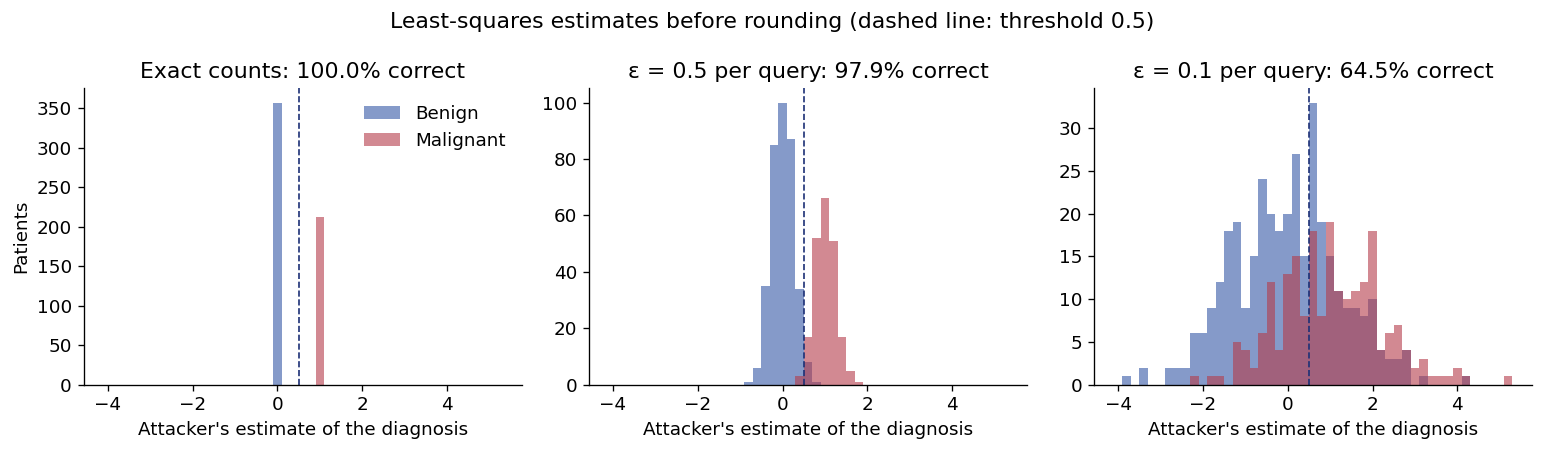

In [8]:
def noisy_answers(epsilon, seed):
    """True count of every attack cohort plus fresh Laplace noise."""
    laplace = Laplace(epsilon=epsilon, sensitivity=1, random_state=seed)
    return np.array([laplace.randomise(count) for count in exact_answers])


panels = [("Exact counts", exact_answers),
          ("ε = 0.5 per query", noisy_answers(0.5, seed=100)),
          ("ε = 0.1 per query", noisy_answers(0.1, seed=100))]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
bins = np.arange(-4.1, 5.4, 0.2)  # bins centred on whole numbers, so 0 and 1 each get one bar
for ax, (name, answers) in zip(axes, panels):
    estimates = solver @ answers
    ax.hist(estimates[diagnosis == 0], bins=bins, color=BLUE, alpha=0.6, label="Benign")
    ax.hist(estimates[diagnosis == 1], bins=bins, color=RED, alpha=0.6, label="Malignant")
    ax.axvline(0.5, color=NAVY, ls="--", lw=1)
    ax.set(title=f"{name}: {reconstruction_rate(answers):.1%} correct",
           xlabel="Attacker's estimate of the diagnosis")
axes[0].set_ylabel("Patients")
axes[0].legend(frameon=False)
fig.suptitle("Least-squares estimates before rounding (dashed line: threshold 0.5)")
fig.tight_layout()
plt.show()

## 4. Privacy and accuracy across ε

Now we repeat the attack for seven values of ε per query, with five noise draws each. By sequential
composition the ε of every answer adds up, so one attack of 1,138 queries costs 1,138 × ε per query
in total.
We also measure how far the noisy counts are from the true counts. That is the accuracy an honest
analyst gives up.

In [9]:
EPSILONS = [0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
TRIALS = 5

rows = []
for epsilon in EPSILONS:
    reconstructed, count_errors = [], []
    for trial in range(TRIALS):
        answers = noisy_answers(epsilon, seed=100 + trial)
        reconstructed.append(100 * reconstruction_rate(answers))
        count_errors.append(np.mean(np.abs(answers - exact_answers)))
    rows.append({"ε per query": epsilon, "total ε": n_queries * epsilon,
                 "reconstructed (%)": np.mean(reconstructed), "trial SD (%)": np.std(reconstructed),
                 "mean count error": np.mean(count_errors)})

results = pd.DataFrame(rows)
results.round(3)

,ε per query,total ε,reconstructed (%),trial SD (%),mean count error
0,0.02,22.76,54.446,1.955,50.055
1,0.05,56.90,58.489,2.182,20.022
2,0.10,113.80,66.257,1.291,10.011
3,0.20,227.60,80.105,0.827,5.006
4,0.30,341.40,89.561,1.869,3.337
5,0.50,569.00,97.891,0.882,2.002
6,1.00,1138.00,100.000,0.000,1.001


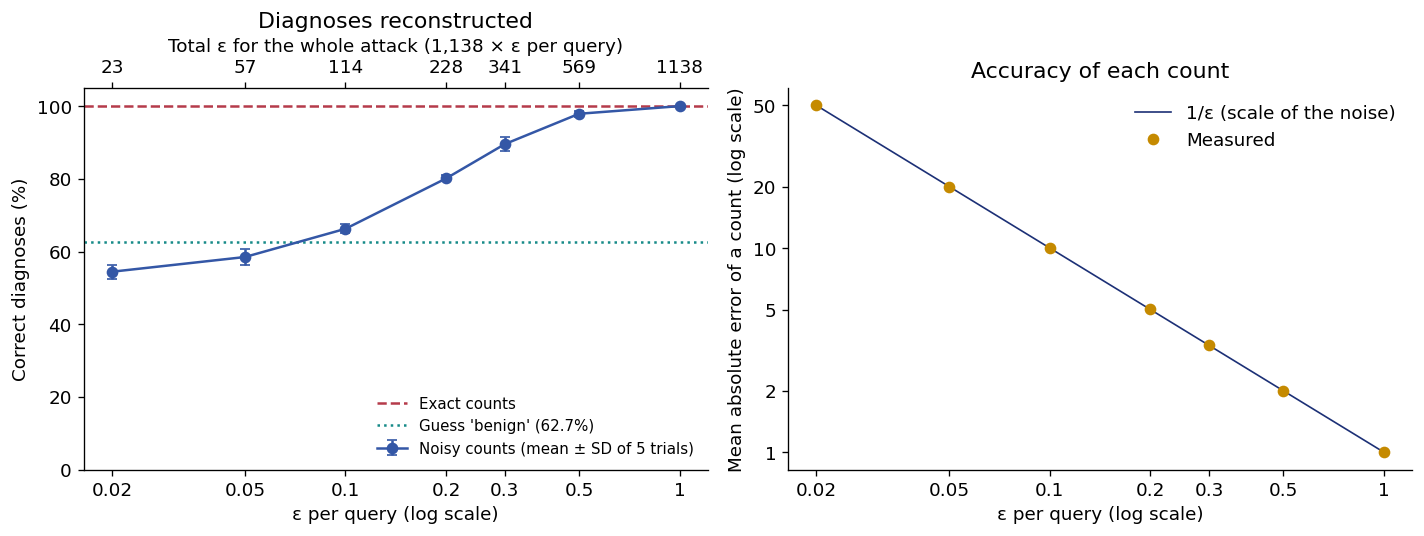

In [10]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.6))
for ax in (left, right):
    ax.set_xscale("log")
    ax.set_xticks(EPSILONS, [f"{e:g}" for e in EPSILONS])
    ax.minorticks_off()
    ax.set_xlabel("ε per query (log scale)")

left.errorbar(results["ε per query"], results["reconstructed (%)"], yerr=results["trial SD (%)"],
              marker="o", capsize=3, color=BLUE, label="Noisy counts (mean ± SD of 5 trials)")
left.axhline(100, color=RED, ls="--", label="Exact counts")
left.axhline(100 * majority, color=TEAL, ls=":", label=f"Guess 'benign' ({majority:.1%})")
left.set(ylim=(0, 105), title="Diagnoses reconstructed", ylabel="Correct diagnoses (%)")
left.legend(fontsize=9, loc="lower right", frameon=False)
# Top axis: what the whole attack costs
top = left.secondary_xaxis("top", functions=(lambda e: e * n_queries, lambda t: t / n_queries))
top.set_ticks([n_queries * e for e in EPSILONS], [f"{n_queries * e:.0f}" for e in EPSILONS])
top.minorticks_off()
top.set_xlabel(f"Total ε for the whole attack ({n_queries:,} × ε per query)")

eps_grid = np.geomspace(EPSILONS[0], EPSILONS[-1], 100)
right.plot(eps_grid, 1 / eps_grid, color=NAVY, lw=1, label="1/ε (scale of the noise)")
right.plot(results["ε per query"], results["mean count error"], "o", color=GOLD, label="Measured")
right.set_yscale("log")  # on log-log axes 1/ε is a straight line
right.set_yticks([1, 2, 5, 10, 20, 50], ["1", "2", "5", "10", "20", "50"])
right.minorticks_off()
right.set(title="Accuracy of each count", ylabel="Mean absolute error of a count (log scale)")
right.legend(frameon=False)
fig.tight_layout()
plt.show()

At ε = 0.02 and 0.05 per query the attack does worse than guessing "benign" for everyone. From
ε = 0.5 it recovers almost every diagnosis. The count error is close to 1/ε, the scale of the noise.

The attack does well even when the noise on each answer is larger than one patient's contribution,
because its 1,138 overlapping questions average much of the noise away. It is the same effect as
asking one question many times, and it is why privacy loss has to be counted over all answers.

The per-query values look small, but the totals do not. Even ε = 0.02 per query adds up to 22.76
over the whole attack, and ε = 1 per query adds up to 1,138. For comparison, the entire 2020 US Census
redistricting release used a total budget of about ε = 19.6.

## 5. A privacy budget

Noise alone does not stop someone who keeps asking. Averaging repeated answers brings the estimate
back towards the true value, and small changes to the question get around a simple block on
repeats. So the service sets a total budget in advance, charges every answer against it, and
checks the remaining budget *before* it releases the next answer. diffprivlib's
`BudgetAccountant` does the bookkeeping.

Here the total budget is ε = 1.0 and each answer costs 0.25, so four answers fit.

In [11]:
class PrivateCountService:
    """Answers noisy counts and charges each one to the dataset's accountant."""

    def __init__(self, accountant, epsilon_per_query, random_state=None):
        self.accountant = accountant
        self.epsilon = epsilon_per_query
        self.laplace = Laplace(epsilon=epsilon_per_query, sensitivity=1, random_state=random_state)

    def noisy_count(self, patient_ids):
        self.accountant.check(self.epsilon, delta=0)  # raises BudgetError before any data is read
        answer = self.laplace.randomise(count_malignant(patient_ids))
        self.accountant.spend(self.epsilon, delta=0)
        return answer


# One accountant for this dataset: every service that answers about these patients shares it
# δ (delta) allows a small chance that the ε guarantee fails. Laplace needs none, so δ = 0.
budget = BudgetAccountant(epsilon=1.0, delta=0)
# Fixed seed so the output is repeatable. A real service keeps random_state=None.
service = PrivateCountService(budget, epsilon_per_query=0.25, random_state=19)

cohort = np.arange(50)
for query in range(1, 6):
    try:
        answer = service.noisy_count(cohort)
        spent, _ = budget.total()  # (ε, δ) spent so far
        print(f"Query {query}: answer {answer:4.1f}, budget spent {spent:.2f} of 1.00")
    except BudgetError:
        print(f"Query {query}: refused (BudgetError), nothing released")
print(f"True count, known only to the hospital: {count_malignant(cohort)}")

Query 1: answer 43.7, budget spent 0.25 of 1.00
Query 2: answer 40.9, budget spent 0.50 of 1.00
Query 3: answer 36.1, budget spent 0.75 of 1.00
Query 4: answer 45.3, budget spent 1.00 of 1.00
Query 5: refused (BudgetError), nothing released
True count, known only to the hospital: 43


The fifth query is refused before the service looks at a diagnosis. Against the attack in
section 2, this service would stop after 4 of the 1,138 questions.

The accountant belongs to the data, not to one service. A second service that shares `budget`
would be refused straight away. A service with its own fresh accountant would start spending from
zero again, and that is the loophole a single accountant per dataset closes.

## Experiments

1. Change `n_queries` to `n_patients // 2` or `4 * n_patients` and rerun sections 2 to 4. How do the
   reconstruction rate and the total ε change?
2. Fix the total budget for the whole attack at ε = 10: set `EPSILONS = [10 / n_queries]`. How does
   the attacker compare with the 62.7% baseline?
3. Create a new `BudgetAccountant(epsilon=10, delta=0)` and a service with
   `epsilon_per_query=0.1`, then ask about the same cohort until it refuses. How many answers do
   you get, and how close is their average to the true count?
4. Make the cohorts smaller: in section 2, replace the `query_matrix` line with
   `query_matrix = (rng.random((n_queries, n_patients)) < 0.1).astype(int)` and rerun sections 2
   to 4. Does the attack on exact counts still work? What happens with noise?

**References:** [diffprivlib mechanisms](https://diffprivlib.readthedocs.io/en/latest/modules/mechanisms.html) ·
[diffprivlib BudgetAccountant](https://diffprivlib.readthedocs.io/en/latest/modules/accountant.html) ·
[Dinur and Nissim, Revealing information while preserving privacy (2003)](https://doi.org/10.1145/773153.773173) ·
[Dwork and Roth, The Algorithmic Foundations of Differential Privacy (2014)](https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf)